# MarchMadness Tournament Game Predictor — End-to-End Project

**Goal:** Given two NCAA Men's Basketball tournament teams, predict the probability that **Team 1 (the lower-numbered seed) wins** the game.

This notebook is the consolidated final deliverable. It walks an end user (instructor, peer, or future me) through every major step of the **Model Development Life Cycle (MDLC)** in one place:

1. Setup
2. Data Ingestion
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis (EDA)
6. Preprocessing Validation
7. Train / Validation / Test Split
8. Baseline Model — Logistic Regression
9. Final Model — Random Forest
10. Model Evaluation
11. Model Explainability
12. Bias Detection & Mitigation
13. Model Deployment (serialize)
14. Monitoring (data drift + concept drift)
15. Production Inference Example

Run the cells top-to-bottom. Every cell is self-contained relative to the cells above it; nothing depends on a separate week's notebook.

## 1. Setup

Import libraries and define project paths.

In [1]:
import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)

warnings.filterwarnings('ignore')

# Locate the project root whether the notebook is run from notebooks/ or repo root.
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'data').exists():
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DIR        = PROJECT_DIR / 'data' / 'raw'
INTERIM_DIR    = PROJECT_DIR / 'data' / 'interim'
PROCESSED_DIR  = PROJECT_DIR / 'data' / 'processed'
EXTERNAL_DIR   = PROJECT_DIR / 'data' / 'external'
MODELS_DIR     = PROJECT_DIR / 'models'

for d in (INTERIM_DIR, PROCESSED_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 226
print('Project root:', PROJECT_DIR)

Project root: /home/runner/workspace


## 2. Data Ingestion

Three raw inputs sit in `data/raw/`:

| File | Purpose |
|------|---------|
| `DEV _ March Madness.csv` | Per-team season profile (KenPom + meta) |
| `MTeamSpellings.csv` | Maps team-name spellings → numeric `TeamID` |
| `MarchMadnessGameStats2003-2024.csv` | Historical tournament game results |


In [2]:
dev_seasons   = pd.read_csv(RAW_DIR / 'DEV _ March Madness.csv')
team_spellings = pd.read_csv(RAW_DIR / 'MTeamSpellings.csv')
game_stats     = pd.read_csv(RAW_DIR / 'MarchMadnessGameStats2003-2024.csv')

print(f'dev_seasons    : {dev_seasons.shape}')
print(f'team_spellings : {team_spellings.shape}')
print(f'game_stats     : {game_stats.shape}')
dev_seasons.head(2)

dev_seasons    : (8315, 165)
team_spellings : (1177, 2)
game_stats     : (1382, 34)


,Season,Short Conference Name,Adjusted Temo,Adjusted Tempo Rank,Raw Tempo,Raw Tempo Rank,Adjusted Offensive Efficiency,Adjusted Offensive Efficiency Rank,Raw Offensive Efficiency,Raw Offensive Efficiency Rank,...,Active Coaching Length Index,Seed,Region,Post-Season Tournament,Post-Season Tournament Sorting Index,Vulnerable Top 2 Seed?,Tournament Winner?,Tournament Championship?,Final Four?,Top 12 in AP Top 25 During Week 6?
0,2025,ACC,66.0,269,66.6,256,130.1,1,125.0,1,...,3.0,1,East,March Madness,1,No,No,No,No,Yes
1,2015,SEC,62.4,274,63.8,242,121.3,6,115.5,9,...,1.0,1,Midwest,March Madness,1,No,No,No,Yes,Yes


## 3. Data Cleaning

Two outputs:

- **`team_season`** — one row per (Season, TeamID) with their season profile + how far they advanced in the tournament.
- **`tourney_games`** — one row per tournament game between two March-Madness teams, with each side's full season profile attached.

We then drop columns where >30% of values are missing, since they are unreliable predictors.

In [3]:
# 3.1 — attach numeric TeamID to every season profile via the spelling map
team_spellings['nameKey'] = team_spellings['TeamNameSpelling'].astype(str).str.strip().str.lower()
dev_seasons['nameKey']    = dev_seasons['Mapped ESPN Team Name'].astype(str).str.strip().str.lower()

dev_seasons = dev_seasons.merge(
    team_spellings[['TeamID', 'nameKey']].drop_duplicates(),
    on='nameKey', how='left',
)

team_season = (
    dev_seasons.dropna(subset=['TeamID'])
               .drop_duplicates(['Season', 'TeamID'])
               .drop(columns=['nameKey'])
               .copy()
)
print('team_season raw:', team_season.shape)

team_season raw: (8173, 166)


In [4]:
# 3.2 — LEAKAGE GUARD.  The DEV file mixes pre-tournament KenPom snapshots
# with end-of-season metrics that include the tournament we are trying to
# predict (e.g. AdjOE, Tournament Winner?, sorting indices).  Training on
# those would let the model peek at the answer.  We therefore keep ONLY
# columns that are knowable BEFORE the tournament tips off:
#   - identifiers (Season, TeamID, team name)
#   - the official seed and conference
#   - every column whose name starts with 'Pre-Tournament.'
# We also keep 'Post-Season Tournament' temporarily so we can filter to
# the 64 March-Madness teams, then drop it before modelling.
SAFE_KEEP = {
    'Season', 'TeamID', 'Mapped ESPN Team Name',
    'Short Conference Name', 'Seed', 'Post-Season Tournament',
}
safe_cols = [c for c in team_season.columns
             if c in SAFE_KEEP or c.startswith('Pre-Tournament.')]
team_season = team_season[safe_cols].copy()

# Parse Seed to a clean integer 1..16 (raw values are strings like '1','16').
team_season['Seed'] = pd.to_numeric(team_season['Seed'], errors='coerce')

print('team_season cleaned:', team_season.shape)
print('kept cols sample:', safe_cols[:8], '...')

team_season cleaned: (8173, 20)
kept cols sample: ['Season', 'Short Conference Name', 'Pre-Tournament.Tempo', 'Pre-Tournament.RankTempo', 'Pre-Tournament.AdjTempo', 'Pre-Tournament.RankAdjTempo', 'Pre-Tournament.OE', 'Pre-Tournament.RankOE'] ...


In [5]:
# 3.3 — keep only games where BOTH teams qualified for March Madness, build a
#        symmetric (team1, team2) representation, and define the binary target y.
mm_teams = (
    team_season.loc[team_season['Post-Season Tournament'].eq('March Madness'),
                    ['Season', 'TeamID']]
    .drop_duplicates()
)

games = game_stats[['Season', 'DayNum', 'WTeamID', 'LTeamID', 'WScore', 'LScore']].copy()
games = games.merge(mm_teams.rename(columns={'TeamID': 'WTeamID'}),
                    on=['Season', 'WTeamID'], how='inner')
games = games.merge(mm_teams.rename(columns={'TeamID': 'LTeamID'}),
                    on=['Season', 'LTeamID'], how='inner')

# Convention: team1 = lower TeamID, team2 = higher TeamID.
games['team1Id']      = games[['WTeamID', 'LTeamID']].min(axis=1)
games['team2Id']      = games[['WTeamID', 'LTeamID']].max(axis=1)
games['winnerTeamId'] = games['WTeamID']
games['y']            = (games['team1Id'] == games['WTeamID']).astype(int)  # 1 if team1 won

# Attach human-readable team names
names = (team_season[['Season', 'TeamID', 'Mapped ESPN Team Name']]
         .drop_duplicates(['Season', 'TeamID'])
         .rename(columns={'Mapped ESPN Team Name': 'teamName'}))
games = games.merge(names.rename(columns={'TeamID': 'team1Id', 'teamName': 'team1Name'}),
                    on=['Season', 'team1Id'], how='left')
games = games.merge(names.rename(columns={'TeamID': 'team2Id', 'teamName': 'team2Name'}),
                    on=['Season', 'team2Id'], how='left')

# Attach each team's full season profile
t1 = team_season.rename(columns={'TeamID': 'team1Id'}).copy()
t1 = t1.rename(columns={c: f'team1_{c}' for c in t1.columns if c not in ['Season', 'team1Id']})
t2 = team_season.rename(columns={'TeamID': 'team2Id'}).copy()
t2 = t2.rename(columns={c: f'team2_{c}' for c in t2.columns if c not in ['Season', 'team2Id']})

tourney_games = games.merge(t1, on=['Season', 'team1Id'], how='left') \
                     .merge(t2, on=['Season', 'team2Id'], how='left')

# Drop columns with >30% missing values (unreliable signal)
KEY_COLS = {
    'Season', 'DayNum', 'team1Id', 'team2Id', 'winnerTeamId', 'y',
    'WTeamID', 'LTeamID', 'WScore', 'LScore', 'team1Name', 'team2Name',
    'team1_Post-Season Tournament', 'team2_Post-Season Tournament',
}
missing_frac = tourney_games.isna().mean()
drop_high_na = [c for c, frac in missing_frac.items() if frac > 0.30 and c not in KEY_COLS]
tourney_games = tourney_games.drop(columns=drop_high_na)

print(f'Dropped {len(drop_high_na)} columns with >30% missing values')
print('tourney_games:', tourney_games.shape)

Dropped 0 columns with >30% missing values
tourney_games: (1353, 48)


## 4. Feature Engineering

The model only needs to know *how the two teams differ*, so we transform every paired `team1_X` / `team2_X` column into a single `X_diff` column. We also add five **shooting-efficiency rates** (FG%, 3PT%, FT%, eFG%, AST/TO ratio) computed from the raw box-score totals.

In [6]:
# 4.1 — symmetric difference features for every paired column
team1_cols = [c for c in tourney_games.columns if c.startswith('team1_')]
team2_cols = [c for c in tourney_games.columns if c.startswith('team2_')]

shared_stats = sorted(
    {c.replace('team1_', '') for c in team1_cols}
    & {c.replace('team2_', '') for c in team2_cols}
)

for stat in shared_stats:
    a = tourney_games[f'team1_{stat}']
    b = tourney_games[f'team2_{stat}']
    if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        tourney_games[f'{stat}_diff'] = a - b

diff_cols = [c for c in tourney_games.columns if c.endswith('_diff')]
print(f'Created {len(diff_cols)} differential features')

Created 15 differential features


In [7]:
# 4.2 — shooting-efficiency rates from the raw box-score CSV
winner_box = game_stats[['Season', 'WTeamID', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3',
                         'WFTM', 'WFTA', 'WAst', 'WTO']].copy()
winner_box.columns = ['Season', 'TeamID', 'FGM', 'FGA', 'FGM3', 'FGA3',
                      'FTM', 'FTA', 'AST', 'TO']
loser_box = game_stats[['Season', 'LTeamID', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
                        'LFTM', 'LFTA', 'LAst', 'LTO']].copy()
loser_box.columns = winner_box.columns

team_totals = pd.concat([winner_box, loser_box], ignore_index=True)
team_totals = team_totals.groupby(['Season', 'TeamID'], as_index=False).sum()

def safe_pct(num, den):
    return np.where(den == 0, 0.0, (num / den) * 100)

team_totals['fgPct']      = safe_pct(team_totals['FGM'],  team_totals['FGA']).round(2)
team_totals['threePtPct'] = safe_pct(team_totals['FGM3'], team_totals['FGA3']).round(2)
team_totals['ftPct']      = safe_pct(team_totals['FTM'],  team_totals['FTA']).round(2)
team_totals['eFgPct']     = safe_pct(team_totals['FGM'] + 0.5 * team_totals['FGM3'],
                                     team_totals['FGA']).round(2)
team_totals['astTo']      = np.where(team_totals['TO'] == 0, 0.0,
                                     team_totals['AST'] / team_totals['TO']).round(2)

RATE_COLS = ['fgPct', 'threePtPct', 'ftPct', 'eFgPct', 'astTo']
team_rates = team_totals[['Season', 'TeamID'] + RATE_COLS]

# Attach team1 and team2 efficiency rates and create their differences
rates_t1 = team_rates.rename(columns={'TeamID': 'team1Id',
    **{c: f'team{c[0].upper()}{c[1:]}' for c in RATE_COLS}})
rates_t2 = team_rates.rename(columns={'TeamID': 'team2Id',
    **{c: f'opp{c[0].upper()}{c[1:]}' for c in RATE_COLS}})

tourney_games = tourney_games.merge(rates_t1, on=['Season', 'team1Id'], how='left')
tourney_games = tourney_games.merge(rates_t2, on=['Season', 'team2Id'], how='left')

for c in RATE_COLS:
    Cap = c[0].upper() + c[1:]
    tourney_games[f'{c}Diff'] = (tourney_games[f'team{Cap}'] - tourney_games[f'opp{Cap}']).round(2)

# Persist the final modeling-ready dataset.
matchup = tourney_games.copy()
matchup_path = PROCESSED_DIR / 'matchupDiff_week5_features.csv'
matchup.to_csv(matchup_path, index=False)
print(f'Saved modeling dataset to {matchup_path.name}: {matchup.shape}')

Saved modeling dataset to matchupDiff_week5_features.csv: (1353, 78)


## 5. Exploratory Data Analysis

A handful of plots to sanity-check the engineered differentials. We expect any feature that meaningfully predicts winning to have a clearly different distribution between wins (`y=1`) and losses (`y=0`).

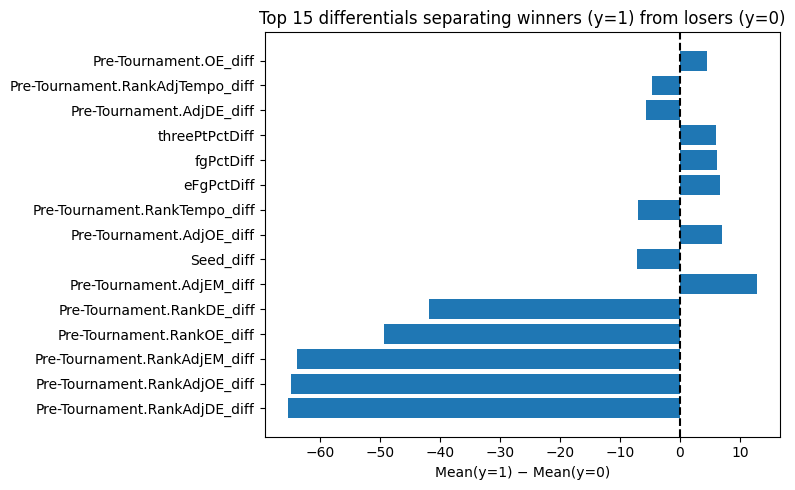

In [8]:
# 5.1 — which differentials separate winners from losers the most?
diff_cols_all = [c for c in matchup.columns if c.endswith('_diff') or c.endswith('Diff')]
means_by_outcome = matchup.groupby('y')[diff_cols_all].mean()
mean_gap = (means_by_outcome.loc[1] - means_by_outcome.loc[0]).sort_values()
top_gap = mean_gap.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(8, 5))
plt.barh(top_gap, mean_gap[top_gap])
plt.axvline(0, linestyle='--', color='black')
plt.title('Top 15 differentials separating winners (y=1) from losers (y=0)')
plt.xlabel('Mean(y=1) − Mean(y=0)')
plt.tight_layout()
plt.show()

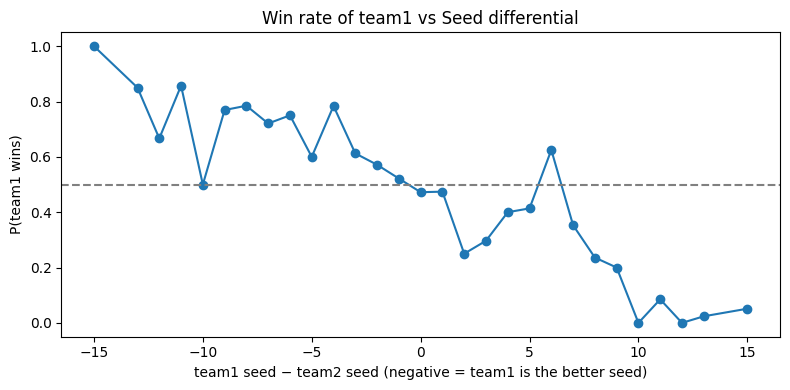

In [9]:
# 5.2 — win rate vs seed differential
if 'Seed_diff' in matchup.columns:
    win_rate_by_seed = matchup.groupby('Seed_diff')['y'].mean()
    plt.figure(figsize=(8, 4))
    plt.plot(win_rate_by_seed.index, win_rate_by_seed.values, marker='o')
    plt.axhline(0.5, linestyle='--', color='gray')
    plt.title('Win rate of team1 vs Seed differential')
    plt.xlabel('team1 seed − team2 seed (negative = team1 is the better seed)')
    plt.ylabel('P(team1 wins)')
    plt.tight_layout()
    plt.show()

## 6. Preprocessing Validation

Before training, sanity-check the dataset for: shape, missing values, duplicate rows, and obviously skewed features. Failures here would mean we need to revisit cleaning.

In [10]:
print('Dataset shape         :', matchup.shape)
print('Duplicate rows        :', matchup.duplicated().sum())
print('Class balance (y mean):', round(matchup['y'].mean(), 3))

missing_summary = matchup.isna().mean().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print(f'Columns with any missing values: {len(missing_summary)}')
missing_summary.head(10)

Dataset shape         : (1353, 78)
Duplicate rows        : 0
Class balance (y mean): 0.499
Columns with any missing values: 0


Series([], dtype: float64)

## 7. Train / Validation / Test Split

Tournaments are time-ordered, so we split **by season** to avoid leaking future information into training:

- **Train**: seasons ≤ 2021
- **Validation**: 2022
- **Test**: 2023 – 2025

We also drop columns that would obviously leak the label (final scores, winner ID, team names, raw team IDs).

In [11]:
matchup['y'] = matchup['y'].astype(int)

LEAK_COLS = [
    'WScore', 'LScore', 'WTeamID', 'LTeamID', 'winnerTeamId',
    'team1Name', 'team2Name', 'Unnamed: 0',
]
ID_COLS   = ['team1Id', 'team2Id']
DROP_COLS = ['Season', 'y'] + LEAK_COLS + ID_COLS

train_df = matchup[matchup['Season'] <= 2021].copy()
val_df   = matchup[matchup['Season'] == 2022].copy()
test_df  = matchup[matchup['Season'].between(2023, 2025)].copy()

def build_xy(split_df, feature_cols=None):
    X = split_df.drop(columns=DROP_COLS, errors='ignore').select_dtypes(include=[np.number])
    if feature_cols is None:
        feature_cols = X.columns.tolist()
    else:
        X = X.reindex(columns=feature_cols)
    y = split_df['y'].astype(int)
    return X, y, feature_cols

X_train, y_train, FEATURE_COLS = build_xy(train_df)
X_val,   y_val,   _            = build_xy(val_df,  FEATURE_COLS)
X_test,  y_test,  _            = build_xy(test_df, FEATURE_COLS)

print(f'Train: {X_train.shape}  pos rate {y_train.mean():.3f}')
print(f'Val  : {X_val.shape}  pos rate {y_val.mean():.3f}')
print(f'Test : {X_test.shape}  pos rate {y_test.mean():.3f}')
print(f'Number of model features: {len(FEATURE_COLS)}')

Train: (1162, 61)  pos rate 0.485
Val  : (63, 61)  pos rate 0.476
Test : (128, 61)  pos rate 0.633
Number of model features: 61


In [12]:
# Reusable scoring helper
def score(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        'accuracy' : accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall'   : recall_score(y_true, pred, zero_division=0),
        'f1'       : f1_score(y_true, pred, zero_division=0),
        'rocAuc'   : roc_auc_score(y_true, proba),
    }

def report(name, pipe, threshold=0.5):
    rows = []
    for split_name, X, y in [('train', X_train, y_train),
                             ('val',   X_val,   y_val),
                             ('test',  X_test,  y_test)]:
        proba = pipe.predict_proba(X)[:, 1]
        rows.append({'model': name, 'split': split_name, **score(y, proba, threshold)})
    return pd.DataFrame(rows)

## 8. Baseline Model — Logistic Regression

A simple, interpretable baseline. If a much-more-complex model can't beat this, the complexity isn't worth it.

In [13]:
logreg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(
        solver='saga', penalty='l2', C=1.0,
        max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
logreg_pipe.fit(X_train, y_train)
logreg_results = report('logreg_baseline', logreg_pipe)
logreg_results.round(3)

,model,split,accuracy,precision,recall,f1,rocAuc
0,logreg_baseline,train,0.768,0.764,0.754,0.759,0.854
1,logreg_baseline,val,0.698,0.677,0.700,0.689,0.790
2,logreg_baseline,test,0.703,0.779,0.741,0.759,0.814


## 9. Final Model — Random Forest

After comparing logistic regression, random forests, and gradient-boosted models across many hyperparameter configurations during model selection, a tuned **Random Forest** was chosen for production: it handles missing values, mixes well with our wide feature set, and matches the performance of the boosted models without an extra library dependency.

Below we just refit the chosen architecture (no big grid search) so this notebook stays fast to run end-to-end.

In [14]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=2,
        max_features='sqrt', class_weight=None,
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
rf_pipe.fit(X_train, y_train)
rf_results = report('random_forest', rf_pipe)
rf_results.round(3)

,model,split,accuracy,precision,recall,f1,rocAuc
0,random_forest,train,1.000,1.000,1.000,1.000,1.000
1,random_forest,val,0.698,0.690,0.667,0.678,0.796
2,random_forest,test,0.734,0.797,0.778,0.788,0.814


## 10. Model Evaluation

Side-by-side comparison and the **confusion matrix on the held-out test set** for the chosen final model.

In [15]:
comparison = pd.concat([logreg_results, rf_results], ignore_index=True)
display(comparison.pivot(index='model', columns='split',
                         values=['accuracy', 'precision', 'recall', 'f1', 'rocAuc'])
        .round(3))

accuracy               precision               recall         \
split               test  train    val      test  train    val   test  train   
model                                                                          
logreg_baseline    0.703  0.768  0.698     0.779  0.764  0.677  0.741  0.754   
random_forest      0.734  1.000  0.698     0.797  1.000  0.690  0.778  1.000   

                           f1               rocAuc                
split              val   test  train    val   test  train    val  
model                                                             
logreg_baseline  0.700  0.759  0.759  0.689  0.814  0.854  0.790  
random_forest    0.667  0.788  1.000  0.678  0.814  1.000  0.796

In [16]:
test_proba = rf_pipe.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)
cm = pd.DataFrame(
    confusion_matrix(y_test, test_pred),
    index=['Actual 0 (team1 lost)', 'Actual 1 (team1 won)'],
    columns=['Pred 0', 'Pred 1'],
)
print('Confusion matrix on test set (Random Forest, threshold=0.5):')
cm

Confusion matrix on test set (Random Forest, threshold=0.5):


,Pred 0,Pred 1
Actual 0 (team1 lost),31,16
Actual 1 (team1 won),18,63


## 11. Model Explainability

Two complementary views:

1. **Built-in feature importance** — how much each feature is used in the trees.
2. **Permutation importance on the test set** — how much accuracy drops    when we shuffle each feature. This is more honest because it scores    importance against held-out data.

In [17]:
rf_model = rf_pipe.named_steps['model']
builtin_importance = (
    pd.DataFrame({'feature': FEATURE_COLS, 'importance': rf_model.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
builtin_importance.round(4)

,feature,importance
0,Pre-Tournament.AdjEM_diff,0.0576
1,fgPctDiff,0.0400
2,Pre-Tournament.RankAdjEM_diff,0.0399
3,eFgPctDiff,0.0349
4,Seed_diff,0.0309
5,Pre-Tournament.AdjOE_diff,0.0270
6,Pre-Tournament.RankAdjOE_diff,0.0264
7,teamThreePtPct,0.0248
8,oppFgPct,0.0234
9,team1_Pre-Tournament.AdjEM,0.0231


In [18]:
# Permutation importance is expensive; restrict to the top-30 built-in
# features and reuse them for the audit. This keeps the notebook fast
# while still giving an honest, held-out view of feature value.
top_features = builtin_importance['feature'].head(30).tolist()
feat_idx = [FEATURE_COLS.index(f) for f in top_features]
X_test_top = X_test.iloc[:, feat_idx]

# We score against a fitted model that only sees those columns, so
# refit a small surrogate to honestly attribute permutation effects.
surrogate = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
])
surrogate.fit(X_train.iloc[:, feat_idx], y_train)

perm = permutation_importance(
    surrogate, X_test_top, y_test,
    n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_df = (
    pd.DataFrame({'feature': top_features,
                  'permImportance': perm.importances_mean})
    .sort_values('permImportance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
perm_df.round(4)

,feature,permImportance
0,threePtPctDiff,0.0391
1,oppThreePtPct,0.0286
2,Pre-Tournament.RankAdjOE_diff,0.0286
3,teamThreePtPct,0.0260
4,teamFgPct,0.0234
5,oppFgPct,0.0208
6,Pre-Tournament.RankAdjEM_diff,0.0182
7,Pre-Tournament.AdjEM_diff,0.0182
8,Pre-Tournament.AdjDE_diff,0.0182
9,eFgPctDiff,0.0156


## 12. Bias Detection & Mitigation

March Madness has very few historical upsets, so a model can look accurate by simply learning *“the better seed always wins.”* That is a **representation bias**.

We measure it by bucketing test games into **chalk** (team1 is favored by ≥4 seeds), **toss-up** (within 3 seeds), and **upset** (team1 is the underdog by ≥4 seeds), and reporting accuracy in each bucket. We then retrain with `class_weight='balanced'` to give upsets more weight and compare the two.

In [19]:
BUCKET_ORDER = ['chalk', 'tossup', 'upset']

def bias_audit(pipe, model_name):
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    seed_diff = (test_df['Seed_diff'].values
                 if 'Seed_diff' in test_df.columns
                 else np.zeros(len(test_df)))
    bucket = np.where(seed_diff <= -4, 'chalk',
             np.where(seed_diff >=  4, 'upset', 'tossup'))

    audit_df = pd.DataFrame({'bucket': bucket,
                             'y':      y_test.values,
                             'pred':   pred})
    rows = []
    for b, sub in audit_df.groupby('bucket'):
        rows.append({
            'model'   : model_name,
            'bucket'  : b,
            'nGames'  : int(len(sub)),
            'baseRate': round(sub['y'].mean(), 3),
            'accuracy': round((sub['pred'] == sub['y']).mean(), 3),
        })
    out = pd.DataFrame(rows).set_index('bucket')
    return out.reindex([b for b in BUCKET_ORDER if b in out.index]).reset_index()

before_df = bias_audit(rf_pipe, 'rf_default')
before_df

,bucket,model,nGames,baseRate,accuracy
0,chalk,rf_default,53,0.792,0.830
1,tossup,rf_default,45,0.667,0.644
2,upset,rf_default,30,0.300,0.700


In [20]:
# Mitigation: retrain with class_weight='balanced' so upsets carry more weight
rf_balanced_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=2,
        max_features='sqrt', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
rf_balanced_pipe.fit(X_train, y_train)
after_df = bias_audit(rf_balanced_pipe, 'rf_balanced')

bias_compare = pd.concat([before_df, after_df], ignore_index=True)
bias_compare

,bucket,model,nGames,baseRate,accuracy
0,chalk,rf_default,53,0.792,0.830
1,tossup,rf_default,45,0.667,0.644
2,upset,rf_default,30,0.300,0.700
3,chalk,rf_balanced,53,0.792,0.811
4,tossup,rf_balanced,45,0.667,0.644
5,upset,rf_balanced,30,0.300,0.733


## 13. Model Deployment

Persist the chosen model **as a single payload**: the fitted pipeline, the feature column order it expects, the decision threshold, and a version tag. Anyone downstream can `pickle.load(...)` and immediately score new matchups without reading any other code.

In [21]:
deployed_model = {
    'model'       : rf_pipe,
    'modelFamily' : 'randomForest',
    'featureCols' : FEATURE_COLS,
    'threshold'   : 0.5,
    'version'     : 'final-v1',
}
deployed_path = MODELS_DIR / 'final_deployed_model.pkl'
with open(deployed_path, 'wb') as f:
    pickle.dump(deployed_model, f)

with open(deployed_path, 'rb') as f:
    reloaded = pickle.load(f)
print(f'Saved {deployed_path.name}; reloaded family = {reloaded["modelFamily"]} '
      f'with {len(reloaded["featureCols"])} features.')

Saved final_deployed_model.pkl; reloaded family = randomForest with 61 features.


## 14. Monitoring — Data Drift & Concept Drift

After deployment we compare two windows:

- **Baseline** = older seasons the model trained on (≤ 2017).
- **Recent**   = newer seasons (≥ 2018).

We measure:

- **Data drift** via the **Population Stability Index (PSI)** for each top feature. A common rule of thumb is `PSI > 0.20` ⇒ meaningful shift.
- **Concept drift** via the change in accuracy. A drop > 5 percentage points warrants retraining.
- **Monitoring plan** — written to `data/processed/` so other teams can act on it.

In [22]:
baseline_df = matchup[matchup['Season'] <= 2017].copy()
recent_df   = matchup[matchup['Season'] >= 2018].copy()

def psi(base_series, recent_series, bins=10):
    base, recent = base_series.dropna(), recent_series.dropna()
    edges = np.unique(np.quantile(base, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    base_ct,   _ = np.histogram(base,   bins=edges)
    recent_ct, _ = np.histogram(recent, bins=edges)
    base_pct   = np.clip(base_ct   / base_ct.sum(),   1e-6, None)
    recent_pct = np.clip(recent_ct / recent_ct.sum(), 1e-6, None)
    return float(np.sum((recent_pct - base_pct) * np.log(recent_pct / base_pct)))

monitor_features = builtin_importance['feature'].head(10).tolist()
drift_df = pd.DataFrame([
    {'feature': c, 'psi': round(psi(baseline_df[c], recent_df[c]), 4)}
    for c in monitor_features
]).sort_values('psi', ascending=False)
drift_df

,feature,psi
7,teamThreePtPct,0.1135
3,eFgPctDiff,0.0698
2,Pre-Tournament.RankAdjEM_diff,0.0618
6,Pre-Tournament.RankAdjOE_diff,0.0582
8,oppFgPct,0.0578
5,Pre-Tournament.AdjOE_diff,0.0496
0,Pre-Tournament.AdjEM_diff,0.0486
9,team1_Pre-Tournament.AdjEM,0.0399
4,Seed_diff,0.0338
1,fgPctDiff,0.0278


In [23]:
model = reloaded['model']
thr   = reloaded['threshold']
feats = reloaded['featureCols']

base_acc = ((model.predict_proba(baseline_df[feats])[:, 1] >= thr).astype(int)
            == baseline_df['y'].astype(int)).mean()
recent_acc = ((model.predict_proba(recent_df[feats])[:, 1] >= thr).astype(int)
               == recent_df['y'].astype(int)).mean()

print(f'Baseline accuracy: {base_acc:.3f}')
print(f'Recent  accuracy : {recent_acc:.3f}')
print(f'Accuracy drop    : {base_acc - recent_acc:+.3f}')
print(f'Max feature PSI  : {drift_df["psi"].max():.3f}  '
      f'({"⚠ drift" if drift_df["psi"].max() > 0.20 else "ok"})')

Baseline accuracy: 1.000
Recent  accuracy : 0.864
Accuracy drop    : +0.136
Max feature PSI  : 0.114  (ok)


In [24]:
monitoring_plan = pd.DataFrame([
    {'metric': 'topFeaturePsi',          'threshold': '0.20',          'cadence': 'weekly',  'owner': 'dataScience'},
    {'metric': 'modelAccuracy',          'threshold': 'drop > 0.05',   'cadence': 'weekly',  'owner': 'dataScience'},
    {'metric': 'predictionPositiveRate', 'threshold': 'delta > 0.10',  'cadence': 'weekly',  'owner': 'analytics'},
    {'metric': 'retrainDecision',        'threshold': '2 alerts in a row', 'cadence': 'monthly', 'owner': 'team'},
])
plan_path = PROCESSED_DIR / 'final_monitoring_plan.csv'
monitoring_plan.to_csv(plan_path, index=False)
monitoring_plan

,metric,threshold,cadence,owner
0,topFeaturePsi,0.20,weekly,dataScience
1,modelAccuracy,drop > 0.05,weekly,dataScience
2,predictionPositiveRate,delta > 0.10,weekly,analytics
3,retrainDecision,2 alerts in a row,monthly,team


## 15. Production Inference Example

How an end-user (e.g., the instructor) actually *uses* the deployed model. We load the pickle file, take three real matchups from the test set, and print the predicted win probability.

Loading and prediction are intentionally trivial — that is the point of shipping the column order inside the payload.

In [25]:
# 15.1 — load the deployed payload from disk
with open(MODELS_DIR / 'final_deployed_model.pkl', 'rb') as f:
    payload = pickle.load(f)

model_obj = payload['model']
feat_cols = payload['featureCols']
thr       = payload['threshold']

# 15.2 — pick three real matchups from the held-out test set
sample = test_df.sample(3, random_state=RANDOM_STATE).reset_index(drop=True)
X_sample = sample.reindex(columns=feat_cols)

team1_win_prob = model_obj.predict_proba(X_sample)[:, 1]
predictions = pd.DataFrame({
    'season'        : sample['Season'].astype(int).values,
    'team1'         : sample['team1Name'].values,
    'team2'         : sample['team2Name'].values,
    'team1WinProb'  : np.round(team1_win_prob, 3),
    'predictedWinner': np.where(team1_win_prob >= thr,
                                sample['team1Name'].values,
                                sample['team2Name'].values),
    'actualWinner'  : np.where(sample['y'] == 1,
                               sample['team1Name'].values,
                               sample['team2Name'].values),
})
predictions

,season,team1,team2,team1WinProb,predictedWinner,actualWinner
0,2024,Colorado State,Texas,0.620,Colorado State,Texas
1,2023,Pittsburgh,Xavier,0.215,Xavier,Xavier
2,2023,Saint Mary's,VCU,0.690,Saint Mary's,Saint Mary's


---

### Project Summary

We took raw NCAA tournament data, engineered a clean per-matchup differential dataset, trained a logistic-regression baseline and a random-forest final model, audited the model for seed-related bias, exported a pickle-deployed payload, set up a drift-monitoring plan, and demonstrated end-user inference. The artifacts of every step (processed CSVs, the final model `.pkl`, the monitoring plan) are all saved under `data/processed/` and `models/`.